<a href="https://colab.research.google.com/github/rajbhusal2006/DSPY_LAB-EXPERIMENTS/blob/main/DSPY_Exp_4_242601.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Experiment No : 04

##**Aim :**
Learn use of maplotlib library as visualisation tool in data science pipeline to create contour plots, histograms and box plots.

## Performance :

[Students need to execute each and every cell in this section and note the output of the same. Once done they have to answer Questions mentioned in review section]


### Density and Contour plots
Sometimes it is useful to display three-dimensional data in two dimensions using contours or color-coded regions.

There are three Matplotlib functions that can be helpful for this task: ``plt.contour`` for contour plots, ``plt.contourf`` for filled contour plots, and ``plt.imshow`` for showing images.

We will see examples of this type of plot in section below

In [ ]:
get_ipython().run_line_magic('matplotlib', 'inline')
import matplotlib.pyplot as plt
# plt.style.use('seaborn-white') # Commented out as 'seaborn-white' is not a valid style.
import numpy as np

In [ ]:
# A 3D function to plot

def f(x, y):
    return np.sin(x) ** 10 + np.cos(10 + y * x) * np.cos(x)

A contour plot can be created with the ``plt.contour`` function.
It takes three arguments: a grid of *x* values, a grid of *y* values, and a grid of *z* values.

The *x* and *y* values represent positions on the plot, and the *z* values will be represented by the contour levels.

Perhaps the most straightforward way to prepare such data is to use the ``np.meshgrid`` function, which builds two-dimensional grids from one-dimensional arrays:

In [ ]:
# x is set of 50 values between 0 and 5
# x is set of 40 values between 0 and 5

x = np.linspace(0, 5, 50)
y = np.linspace(0, 5, 40)

X, Y = np.meshgrid(x, y)
Z = f(X, Y)

Now let's look at this with a standard line-only contour plot:

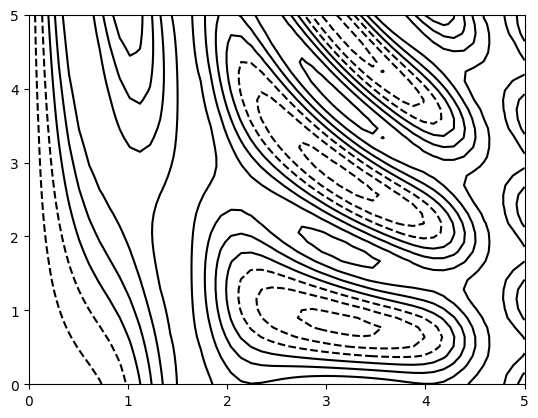

In [ ]:
plt.contour(X, Y, Z, colors='black');

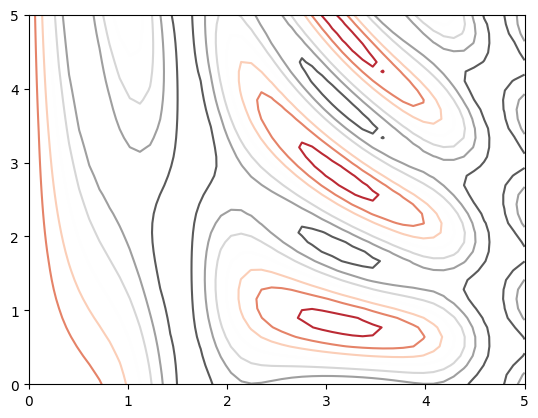

In [ ]:
plt.contour(X, Y, Z, cmap='RdGy');

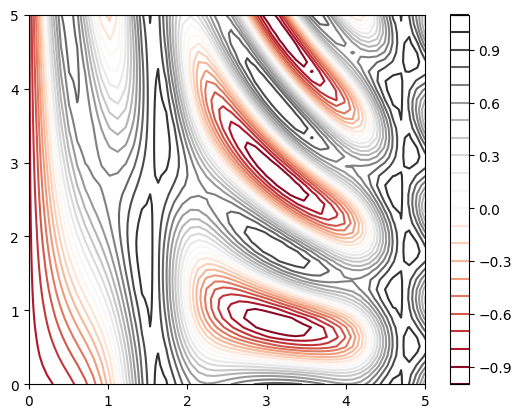

In [ ]:
plt.contour(X, Y, Z, 20, cmap='RdGy');
plt.colorbar();

Answer Following Questions :

Q1.   Explain what are the changes you observe in contour plots above 3 code cells ?

Ans:-

Let's break down the changes you observe in the contour plots from the three code cells:

* **First plot (plt.contour(X, Y, Z, colors='black');):** This plot shows the contour lines in a single, default color (black). It uses a default number of contour levels, which might not be immediately obvious without comparing it to other plots.


* **Second plot (plt.contour(X, Y, Z, cmap='RdGy');):** In this plot, the contour lines are now colored based on a colormap ('RdGy' - Red-Gray). This provides a visual indication of the Z values, with different colors representing different ranges of Z. However, the number of contour levels is still the default.

* **Third plot (plt.contour(X, Y, Z, 20, cmap='RdGy'); plt.colorbar();):** This plot introduces two significant changes:

* The number of contour levels has been explicitly set to 20. This results in a much finer gradation of contour lines, making the changes in Z values more detailed.

* A plt.colorbar() is added. The colorbar provides a legend for the colormap, indicating what Z values correspond to which colors. This makes the plot much more interpretable, as you can now directly relate the colors on the plot to the magnitude of the Z values.

Q2.   What is size of X, Y and Z  respectively ?

Ans:-

In [ ]:
print(f"Size of X: {X.shape}")
print(f"Size of Y: {Y.shape}")
print(f"Size of Z: {Z.shape}")

Size of X: (40, 50)
Size of Y: (40, 50)
Size of Z: (40, 50)


Q.3.   How does colorbar() method help in contour plot.

Ans:-

The colorbar() method is crucial in a contour plot because it provides a visual legend for the colormap used. It maps the colors in the plot to the corresponding Z values (the third dimension being visualized). Without a colorbar, it would be difficult to understand what each color represents in terms of the data's magnitude or range. Essentially, it makes the plot much more interpretable by allowing viewers to relate the visual patterns to actual data values.



### Creating Smoother Contour Plots
One potential issue with this plot is that it is a bit "splotchy." That is, the color steps are discrete rather than continuous, which is not always what is desired.

This could be remedied by setting the number of contours to a very high number, but this results in a rather inefficient plot: Matplotlib must render a new polygon for each step in the level.
A better way to handle this is to use the ``plt.imshow()`` function, which interprets a two-dimensional grid of data as an image.

The following code shows how to perform this:

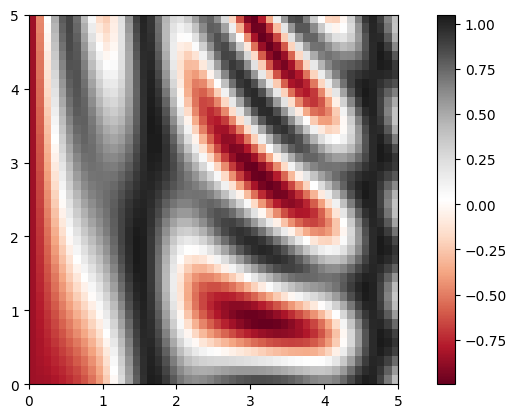

In [ ]:
plt.imshow(Z, extent=[0, 5, 0, 5], origin='lower',
           cmap='RdGy')
plt.colorbar()
plt.axis('image');

Things to remember while using ``imshow()``:

- ``plt.imshow()`` doesn't accept an *x* and *y* grid, so you must manually specify the *extent* [*xmin*, *xmax*, *ymin*, *ymax*] of the image on the plot.
- ``plt.imshow()`` by default follows the standard image array definition where the origin is in the upper left, not in the lower left as in most contour plots. This must be changed when showing gridded data.
- ``plt.imshow()`` will automatically adjust the axis aspect ratio to match the input data; this can be changed by setting, for example, ``plt.axis(aspect='image')`` to make *x* and *y* units match.

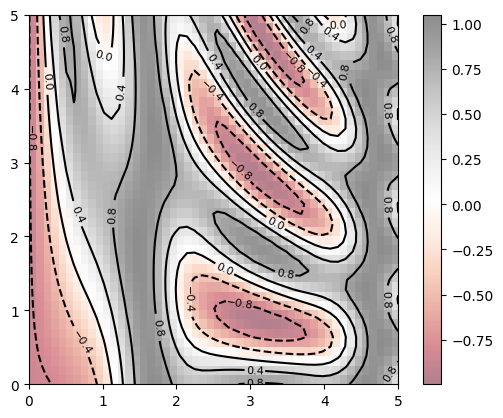

In [ ]:
contours = plt.contour(X, Y, Z, 5, colors='black')
plt.clabel(contours, inline=True, fontsize=8)

plt.imshow(Z, extent=[0, 5, 0, 5], origin='lower',
           cmap='RdGy', alpha=0.5)
plt.colorbar();

Answer Following Questions :

Q1.   What does alpha parameter do ?

Ans:-

The alpha parameter in Matplotlib (and often in other plotting libraries) controls the transparency or opacity of a plotted element. It's a float value typically ranging from 0 to 1:

* alpha=0: Makes the element completely transparent (invisible).

* alpha=1: Makes the element completely opaque (solid).

* Values between 0 and 1: Make the element partially transparent. For example, alpha=0.5 makes it 50% transparent.

This is particularly useful when you want to overlay multiple plots or visualize overlapping data points, as it allows you to see what's underneath.



Q2.   What does clabel method does ?

Ans:-

The clabel() method in Matplotlib is used to add labels to contour lines in a contour plot. These labels typically display the numerical value of the Z level that each contour line represents. This makes the contour plot much more informative, as you can directly read the values of the contours without needing to refer to a colorbar or mentally estimate the levels.

Key parameters for clabel() include:

* contours: The contour object returned by plt.contour().

* inline: If True (default), labels are drawn embedded in the contour lines. If
False, labels are placed next to the lines.

* fontsize: Controls the size of the label text.

Q3.   Recreate above code block after, changing parameter 4 in contour fuction to 5 from 3. Explain what change you see in the plot.

Ans:-

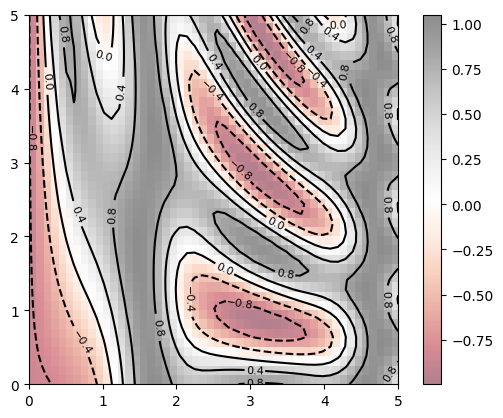

In [ ]:
contours = plt.contour(X, Y, Z, 5, colors='black')
plt.clabel(contours, inline=True, fontsize=8)

plt.imshow(Z, extent=[0, 5, 0, 5], origin='lower',
           cmap='RdGy', alpha=0.5)
plt.colorbar();

### Explanation of the change with 5 contour levels:

When the number of contour levels is set to `5` (as it is in this plot):

*   **Fewer Lines:** Compared to a plot with, for example, `20` contour levels, you will see significantly fewer contour lines. Each line represents a larger change in the `Z` value.
*   **Broader Interpretation:** The plot provides a more generalized view of the data's surface. You can still identify general trends and major changes in `Z`, but the fine details of the terrain are smoothed out.
*   **Clarity:** With fewer lines, the plot might appear less cluttered and easier to read, especially for a quick overview. However, very subtle features might be missed.

If you were to change it *from* `3` to `5` (hypothetically), you would observe a slightly more detailed plot with `5` lines compared to `3`, providing a bit more granularity in representing the `Z` values. If you changed it *from* `20` to `5`, the plot would become much sparser with fewer contour lines.

### Histogram, Binning Plots

A histogram is a graphical representation of a grouped frequency distribution with continuous classes. It is an area diagram and can be defined as a set of rectangles with bases along with the intervals between class boundaries and with areas proportional to frequencies in the corresponding classes. In such representations, all the rectangles are adjacent since the base covers the intervals between class boundaries. The heights of rectangles are proportional to corresponding frequencies of similar classes and for different classes, the heights will be proportional to corresponding frequency densities.

In other words, a histogram is a diagram involving rectangles whose area is proportional to the frequency of a variable and width is equal to the class interval.

The histogram graph is used under certain conditions. They are:



*   The data should be numerical.
*   A histogram is used to check the shape of the data distribution.
*   Used to check whether the process changes from one period to another.
*   Used to determine whether the output is different when it involves two or more processes.
*   Used to analyse whether the given process meets the customer requirements.



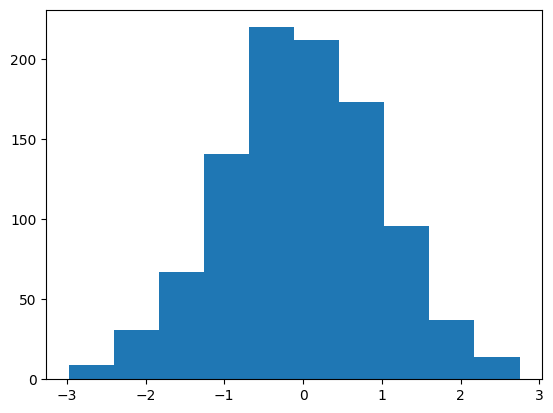

In [ ]:
# How to plot histogram
data = np.random.randn(1000)
plt.hist(data);

The ``hist()`` function has many options to tune both the calculation and the display;
here's an example of a more customized histogram:

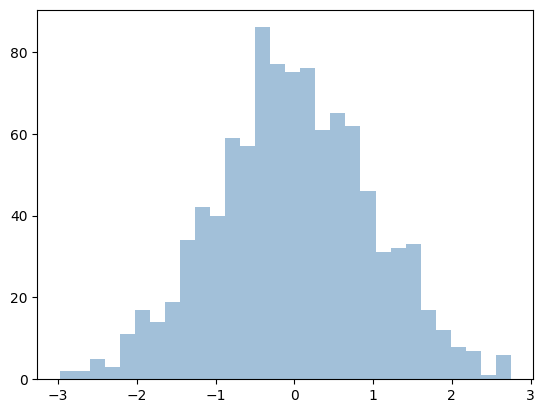

In [ ]:
plt.hist(data, bins=30, alpha=0.5, histtype='stepfilled', color='steelblue', edgecolor='none');

The ``plt.hist`` docstring has more information on other customization options available.
I find this combination of ``histtype='stepfilled'`` along with some transparency ``alpha`` to be very useful when comparing histograms of several distributions:

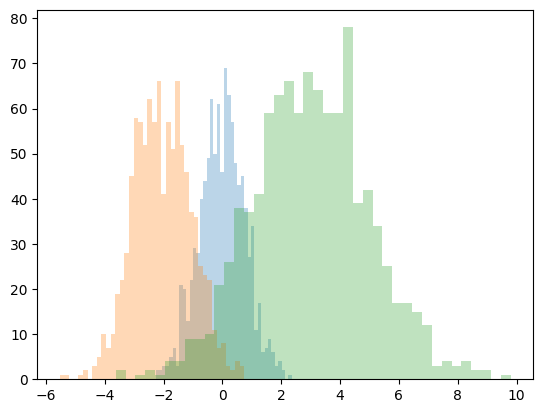

In [ ]:
x1 = np.random.normal(0, 0.8, 1000)
x2 = np.random.normal(-2, 1, 1000)
x3 = np.random.normal(3, 2, 1000)

kwargs = dict(histtype='stepfilled', alpha=0.3, bins=40)

plt.hist(x1, **kwargs)
plt.hist(x2, **kwargs)
plt.hist(x3, **kwargs);

If you would like to simply compute the histogram (that is, count the number of points in a given bin) and not display it, the ``np.histogram()`` function is available:

In [ ]:
#Only storing histogram bin frequencies without ploting it
counts, bin_edges = np.histogram(data, bins=5)
print(counts,bin_edges)

[ 40 208 432 269  51] [-2.97600167 -1.83087068 -0.68573968  0.45939131  1.60452231  2.7496533 ]


### ``plt.hist2d``: Two-dimensional histogram

One straightforward way to plot a two-dimensional histogram is to use Matplotlib's ``plt.hist2d`` function:

In [ ]:
# Create 2 Variable normally distributed data sets with 10000
mean = [0, 0]
cov = [[1, 1], [1, 2]]
x, y = np.random.multivariate_normal(mean, cov, 10000).T

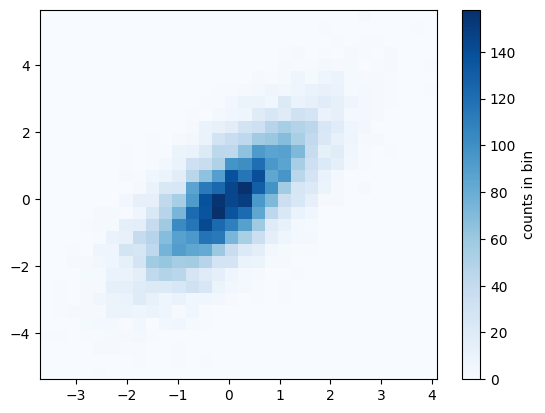

In [ ]:
#Using 2d Histogram plot
plt.hist2d(x, y, bins=30, cmap='Blues')
cb = plt.colorbar()
cb.set_label('counts in bin')

Just as with ``plt.hist``, ``plt.hist2d`` has a number of extra options to fine-tune the plot and the binning, which are nicely outlined in the function docstring.
Further, just as ``plt.hist`` has a counterpart in ``np.histogram``, ``plt.hist2d`` has a counterpart in ``np.histogram2d``, which can be used as follows:

In [ ]:
counts, xedges, yedges = np.histogram2d(x, y, bins=30)

### ``plt.hexbin``: Hexagonal binnings

The two-dimensional histogram creates a tesselation of squares across the axes.
Another natural shape for such a tesselation is the regular hexagon.
For this purpose, Matplotlib provides the ``plt.hexbin`` routine, which will represents a two-dimensional dataset binned within a grid of hexagons:

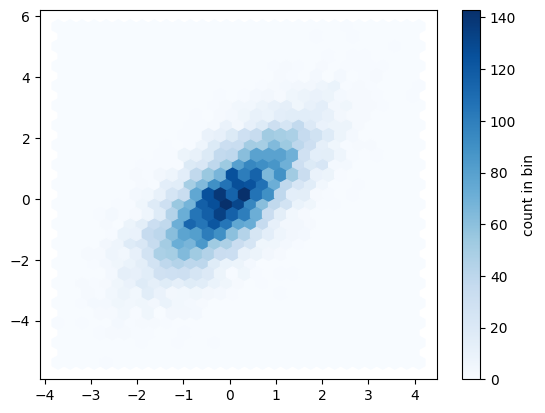

In [ ]:
plt.hexbin(x, y, gridsize=30, cmap='Blues')
cb = plt.colorbar(label='count in bin')

Questions:

Q1.  What is role of bins parameter in histogram plot?

Ans:-

**Definition:** The bins parameter specifies the number or edges of intervals
(bins) into which the range of data values is divided.

**Function:** Each bin represents a range of values, and the histogram visually displays the frequency (count of data points) that fall into each bin.

**Impact on Visualization:**
Fewer bins: Result in wider intervals, providing a more generalized, coarser view of the data distribution, potentially hiding fine details.
More bins: Result in narrower intervals, showing a more detailed, finer-grained view of the data distribution, but can also make the plot appear noisy if too many are used.

**Importance:** Choosing an appropriate number of bins is crucial for accurately representing the underlying shape and characteristics of the data's distribution.

Q2. Create a set of 10000 uniform random samples and store it in variable named *norm_data*. Draw histograms of *norm_data* with following bin counts 5, 50, 500, 5000.

Ans:-

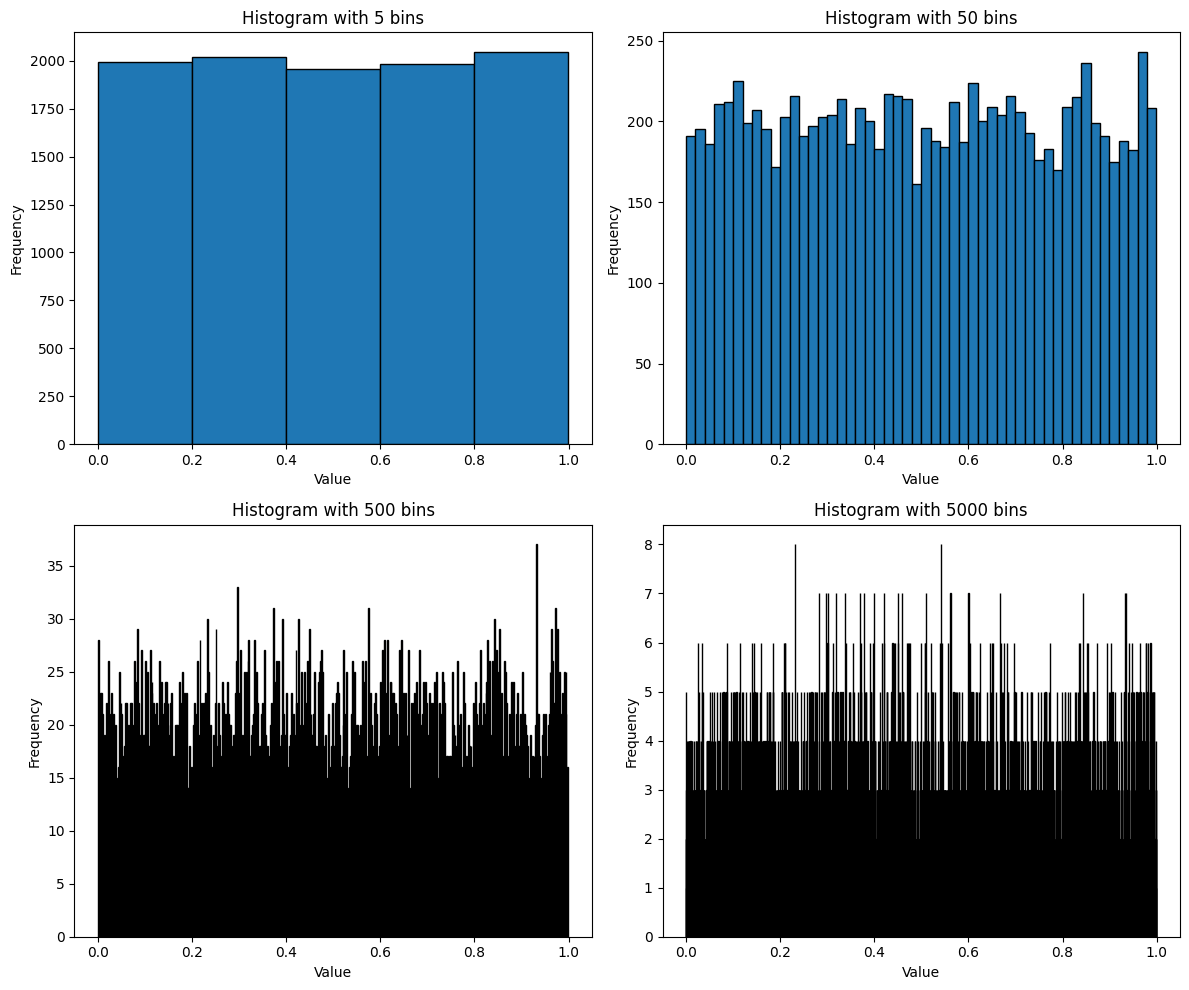

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Create 10000 uniform random samples
norm_data = np.random.rand(10000)

# Define the bin counts to use
bin_counts = [5, 50, 500, 5000]

# Create a figure and a set of subplots
fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(12, 10))
axes = axes.flatten() # Flatten the 2x2 array of axes for easier iteration

for i, bins in enumerate(bin_counts):
    axes[i].hist(norm_data, bins=bins, edgecolor='black')
    axes[i].set_title(f'Histogram with {bins} bins')
    axes[i].set_xlabel('Value')
    axes[i].set_ylabel('Frequency')

plt.tight_layout() # Adjust layout to prevent overlapping titles/labels
plt.show()

Q.3.  Explain your observations in text box of above step.

Ans:-

### Observations:

*   **5 bins:** The histogram is very coarse, showing only a very general shape of the distribution. It's hard to discern any specific patterns.

*   **50 bins:** This provides a much clearer view of the uniform distribution, showing that values are relatively evenly distributed across the range. The bars are distinct enough to see fluctuations in frequency.

*   **500 bins:** With 500 bins, the histogram starts to show more detail, but also becomes quite 'noisy'. The individual bars are very narrow, and the slight variations in frequency become more pronounced, making the overall uniform pattern less smooth.

*   **5000 bins:** This histogram is extremely noisy. The bins are so narrow that many contain only a few data points or even none. It becomes very difficult to interpret the underlying distribution, and the plot appears jagged and fragmented. This demonstrates that too many bins can obscure the overall shape rather than clarify it.

### Ploting from a CSV File

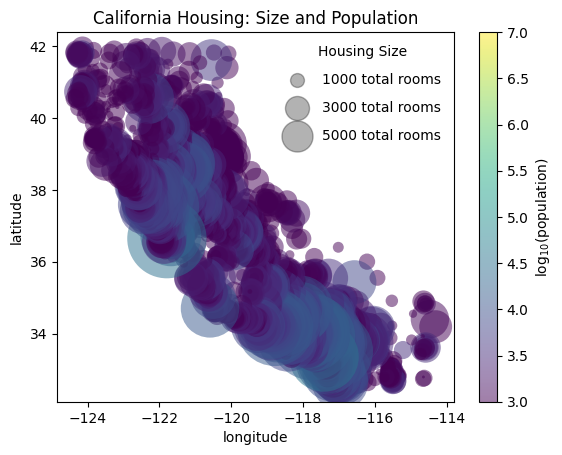

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Assuming housing_df is loaded from '/content/sample_data/california_housing_train.csv' in a previous cell
# If housing_df is not globally accessible, uncomment the following line:
housing_df = pd.read_csv('/content/sample_data/california_housing_train.csv')

# Extract the data we're interested in using the new column names
lat, lon = housing_df['latitude'], housing_df['longitude']
population, area = housing_df['population'], housing_df['total_rooms']

# Scatter the points, using size and color but no label
plt.scatter(lon, lat, label=None,
            c=np.log10(population), cmap='viridis',
            s=area / 10, linewidth=0, alpha=0.5) # Divided area by 10 to scale marker size for better visualization
plt.axis('equal')
plt.xlabel('longitude')
plt.ylabel('latitude')
plt.colorbar(label='log$_{10}$(population)')
plt.clim(3, 7)

# Here we create a legend:
# we'll plot empty lists with the desired size and label
for room_count in [1000, 3000, 5000]: # Adjusted legend values for 'total rooms'
    plt.scatter([], [], c='k', alpha=0.3, s=room_count / 10,
                label=f'{room_count} total rooms') # Updated label text
plt.legend(scatterpoints=1, frameon=False, labelspacing=1, title='Housing Size')

plt.title('California Housing: Size and Population');

### Multiple Subplots
Sometimes it is helpful to compare different views of data side by side. Matplotlib has the concept of *subplots* : groups of smaller axes that can exist together within a single figure.

These subplots might be insets, grids of plots, or other more complicated layouts.

In [ ]:
plt.style.use('seaborn-v0_8-white')
import numpy as np

### ``plt.axes``: Subplots by Hand (Coding)

The most basic method of creating an axes is to use the ``plt.axes`` function. By default this creates a standard axes object that fills the entire figure.

``plt.axes`` also takes an optional argument that is a list of four numbers in the figure coordinate system. These numbers represent
``[left, bottom, width, height]`` in the figure coordinate system, which ranges from 0 at the bottom left of the figure to 1 at the top right of the figure.

For example, we might create an inset axes at the top-right corner of another axes by setting the *x* and *y* position to 0.65 (that is, starting at 65% of the width and 65% of the height of the figure) and the *x* and *y* extents to 0.2 (that is, the size of the axes is 20% of the width and 20% of the height of the figure):

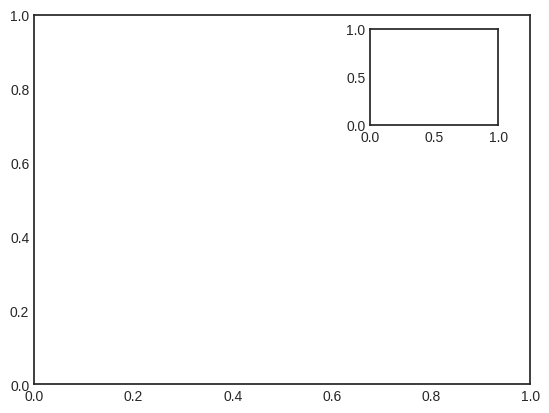

In [ ]:
ax1 = plt.axes()  # standard axes
ax2 = plt.axes([0.650, 0.650, 0.2, 0.2]) #inset axes

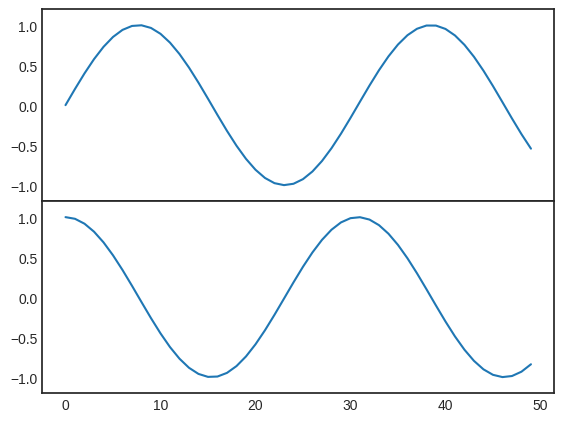

In [ ]:
#creating subplot using fig.add_axes
fig = plt.figure()
ax1 = fig.add_axes([0.1, 0.5, 0.8, 0.4],
                   xticklabels=[], ylim=(-1.2, 1.2))
ax2 = fig.add_axes([0.1, 0.1, 0.8, 0.4],
                   ylim=(-1.2, 1.2))

x = np.linspace(0, 10)
ax1.plot(np.sin(x))
ax2.plot(np.cos(x));

### ``plt.subplot``: Simple Grids of Subplots

Aligned columns or rows of subplots are a common-enough need that Matplotlib has several convenience routines that make them easy to create.

The lowest level of these is ``plt.subplot()``, which creates a single subplot within a grid.

As you can see, this command takes three integer arguments—the number of rows, the number of columns, and the index of the plot to be created in this scheme, which runs from the upper left to the bottom right:

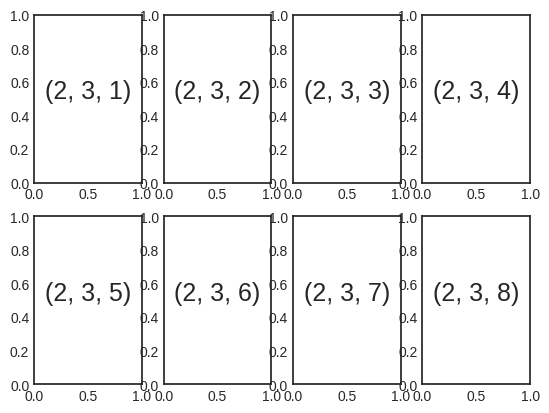

In [ ]:
for i in range(1, 9):
    plt.subplot(2, 4, i)
    plt.text(0.5, 0.5, str((2, 3, i)),
             fontsize=18, ha='center')


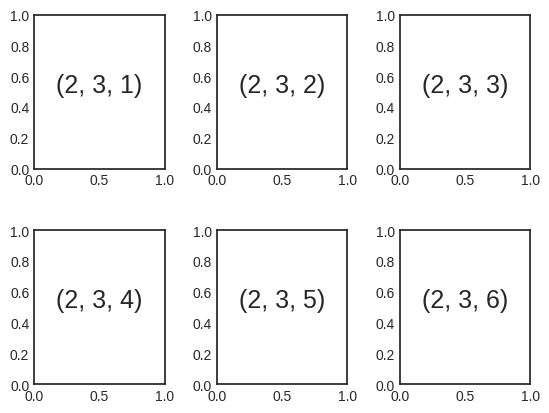

In [ ]:
fig = plt.figure()
fig.subplots_adjust(hspace=0.4, wspace=0.4)
for i in range(1, 7):
    ax = fig.add_subplot(2, 3, i)
    ax.text(0.5, 0.5, str((2, 3, i)),
           fontsize=18, ha='center')

### ``plt.subplots``: The Whole Grid in One Go

The approach just described can become quite tedious when creating a large grid of subplots, especially if you'd like to hide the x- and y-axis labels on the inner plots.
For this purpose, ``plt.subplots()`` is the easier tool to use (note the ``s`` at the end of ``subplots``). Rather than creating a single subplot, this function creates a full grid of subplots in a single line, returning them in a NumPy array.
The arguments are the number of rows and number of columns, along with optional keywords ``sharex`` and ``sharey``, which allow you to specify the relationships between different axes.

Here we'll create a $2 \times 3$ grid of subplots, where all axes in the same row share their y-axis scale, and all axes in the same column share their x-axis scale:

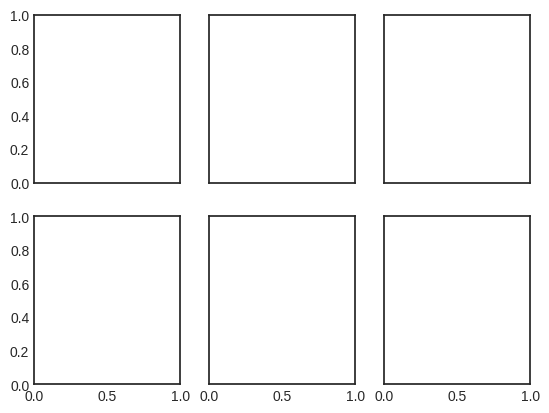

In [ ]:
fig, ax = plt.subplots(2, 3, sharex='col', sharey='row')

Note that by specifying ``sharex`` and ``sharey``, we've automatically removed inner labels on the grid to make the plot cleaner.


The resulting grid of axes instances is returned within a NumPy array, allowing for convenient specification of the desired axes using standard array indexing notation:

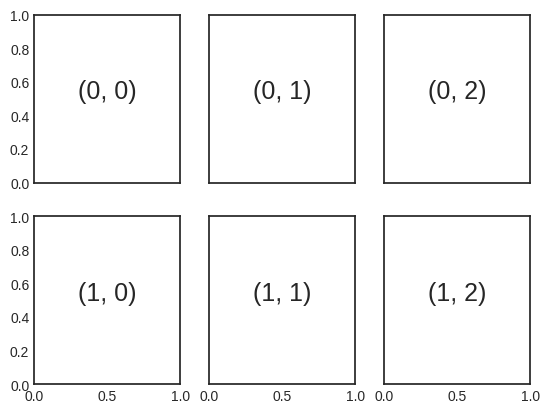

In [ ]:
# axes are in a two-dimensional array, indexed by [row, col]
for i in range(2):
    for j in range(3):
        ax[i, j].text(0.5, 0.5, str((i, j)),
                      fontsize=18, ha='center')
fig

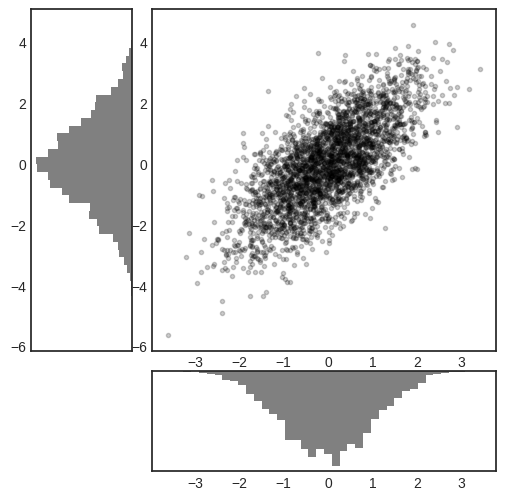

In [ ]:
# An example of Flexible grid arrangement
# Create some normally distributed data
mean = [0, 0]
cov = [[1, 1], [1, 2]]
x, y = np.random.multivariate_normal(mean, cov, 3000).T

# Set up the axes with gridspec
fig = plt.figure(figsize=(6, 6))
grid = plt.GridSpec(4, 4, hspace=0.2, wspace=0.2)
main_ax = fig.add_subplot(grid[:-1, 1:])
y_hist = fig.add_subplot(grid[:-1, 0], xticklabels=[], sharey=main_ax)
x_hist = fig.add_subplot(grid[-1, 1:], yticklabels=[], sharex=main_ax)

# scatter points on the main axes
main_ax.plot(x, y, 'ok', markersize=3, alpha=0.2)

# histogram on the attached axes
x_hist.hist(x, 40, histtype='stepfilled',
            orientation='vertical', color='gray')
x_hist.invert_yaxis()

y_hist.hist(y, 40, histtype='stepfilled',
            orientation='horizontal', color='gray')
y_hist.invert_xaxis()


In [ ]:
import matplotlib as mpl
import pandas as pd
import numpy as np

# Generate synthetic data for demonstration purposes
# In a real scenario, you would ensure 'births.csv' is in the specified path

# Create a date range for a few years
start_date = '2000-01-01'
end_date = '2002-12-31'
dates = pd.date_range(start=start_date, end=end_date, freq='D')

# Create a DataFrame with year, month, day, and synthetic birth counts
synthetic_births = pd.DataFrame({
    'year': dates.year,
    'month': dates.month,
    'day': dates.day,
    'births': np.random.randint(1000, 5000, size=len(dates)) # Random birth counts
})

births = synthetic_births.copy()

quartiles = np.percentile(births['births'], [25, 50, 75])
mu, sig = quartiles[1], 0.74 * (quartiles[2] - quartiles[0])
births = births.query('(births > @mu - 5 * @sig) & (births < @mu + 5 * @sig)')

births['day'] = births['day'].astype(int)

births.index = pd.to_datetime(10000 * births.year +
                              100 * births.month +
                              births.day, format='%Y%m%d')
births_by_date = births.pivot_table('births',
                                    [births.index.month, births.index.day])
births_by_date.index = [pd.to_datetime(f'2012-{month}-{day}') # Use pd.to_datetime directly
                        for (month, day) in births_by_date.index]

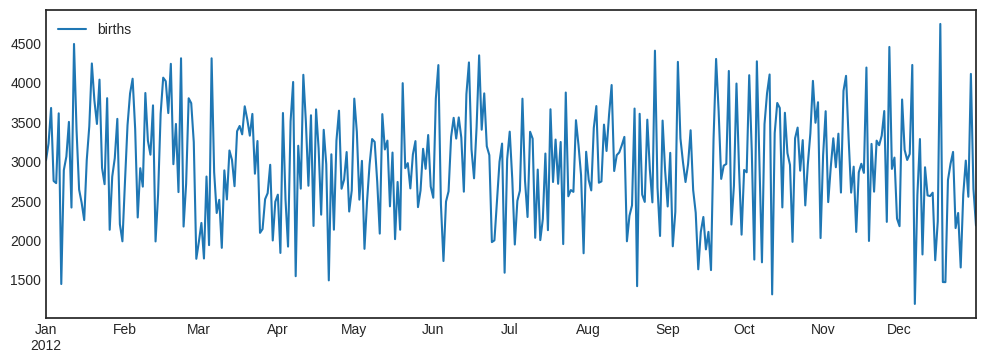

In [ ]:
fig, ax = plt.subplots(figsize=(12, 4))
births_by_date.plot(ax=ax);

### Boxplot

A Box Plot is also known as Whisker plot is created to display the summary of the set of data values having properties like minimum, first quartile, median, third quartile and maximum.

In the box plot, a box is created from the first quartile to the third quartile, a vertical line is also there which goes through the box at the median. Here x-axis denotes the data to be plotted while the y-axis shows the frequency distribution.



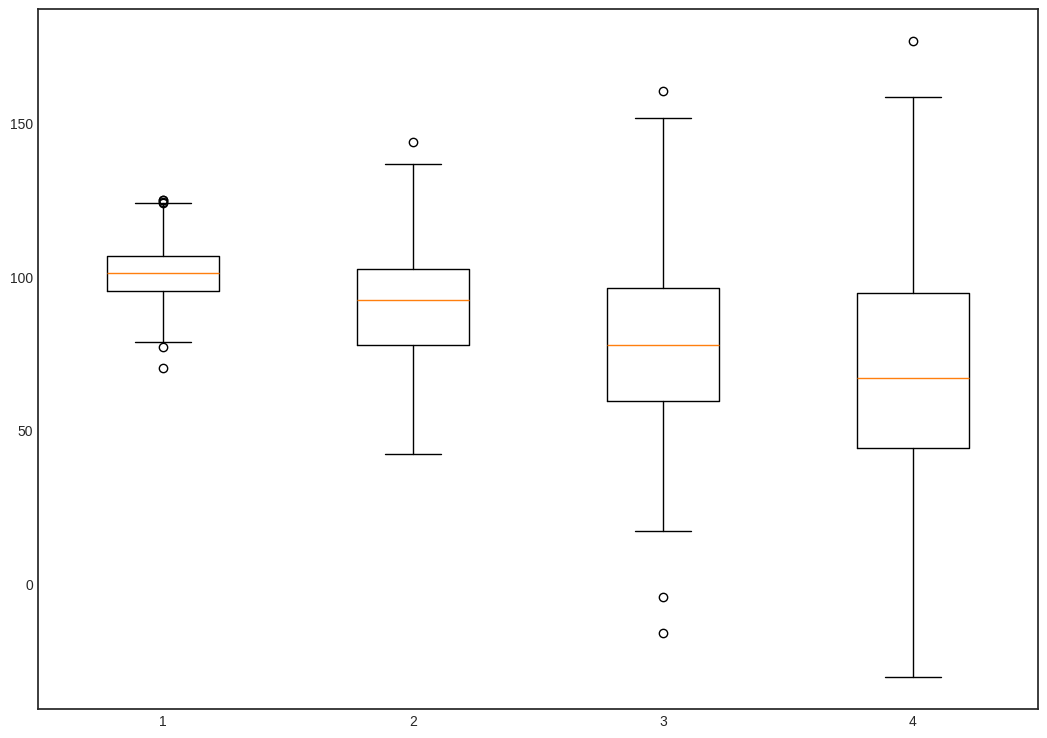

In [ ]:
#Exmple of Box plot for some random data sets
# Import libraries
import matplotlib.pyplot as plt
import numpy as np


# Creating dataset
np.random.seed(10)

data_1 = np.random.normal(100, 10, 200)
data_2 = np.random.normal(90, 20, 200)
data_3 = np.random.normal(80, 30, 200)
data_4 = np.random.normal(70, 40, 200)
data = [data_1, data_2, data_3, data_4]

fig = plt.figure(figsize =(10, 7))

# Creating axes instance
ax = fig.add_axes([0, 0, 1, 1])

# Creating plot
bp = ax.boxplot(data)

# show plot
plt.show()


Questions:


Q1. What is boxplot ?

Ans:-

A Box Plot, also known as a Whisker Plot, is a standardized way to display the distribution of a dataset based on its five-number summary:

* **Minimum:** The lowest data point (excluding outliers).

* **First Quartile (Q1):** The 25th percentile of the data.

* **Median (Q2):** The 50th percentile, which divides the dataset into two halves.

* **Third Quartile (Q3):** The 75th percentile of the data.

* **Maximum:** The highest data point (excluding outliers).

It visually represents the central tendency, spread, and potential outliers of a dataset, making it useful for comparing distributions across different groups.



Q2. What information do we get from a box plot?

Ans:-

From a box plot, we can gather several key pieces of information about the distribution of a dataset:

1. **Central Tendency:** The median (the line inside the box) indicates the central value of the data.

2. **Spread/Dispersion:** The length of the box (from Q1 to Q3) shows the interquartile range (IQR), which represents the middle 50% of the data. The length of the whiskers indicates the overall spread of the data, excluding outliers.

3. **Skewness:** The position of the median within the box and the relative lengths of the whiskers can suggest whether the data distribution is symmetric, positively skewed (median closer to Q1, longer upper whisker), or negatively skewed (median closer to Q3, longer lower whisker).

4. **Outliers:** Individual points plotted beyond the whiskers are identified as potential outliers, indicating values that fall significantly outside the majority of the data.

5. **Five-Number Summary:** It clearly displays the minimum, first quartile (Q1), median (Q2), third quartile (Q3), and maximum values (excluding outliers).

Q3. How is minimum and maximum whisker's marked in a box plot ?

Ans:-

In a box plot, the minimum and maximum whiskers are marked as follows:

* **Upper Whisker:** Extends from the third quartile (Q3) to the highest data point that is no more than 1.5 times the Interquartile Range (IQR) away from Q3. The IQR is the difference between the third quartile (Q3) and the first quartile (Q1), i.e., IQR = Q3 - Q1. So, the upper whisker ends at min(Maximum Value, Q3 + 1.5 * IQR).

* **Lower Whisker:** Extends from the first quartile (Q1) to the lowest data point that is no less than 1.5 times the Interquartile Range (IQR) away from Q1. So, the lower whisker ends at max(Minimum Value, Q1 - 1.5 * IQR).

Any data points falling outside these whiskers are considered potential outliers and are typically plotted individually as dots or asterisks.



Q4. How to we identify that some points in data are outliers by viewing the box plot?

Ans:-

You can identify outliers in a box plot by looking for individual data points plotted outside of the whiskers. These points are typically represented as single dots, circles, or asterisks.

Q5. Read a data file from your drive and for all numeric columns plot boxplot.

Ans:-

* **Upload Data File:** Prompt the user to upload a data file (e.g., CSV, Excel) from their local drive. The file will be used to create box plots.

* **Load Data and Identify Numeric Columns:** Read the uploaded data file into a pandas DataFrame. Automatically identify and select all columns with numeric data types.

* **Generate Box Plots:** Create box plots for all identified numeric columns. Each box plot will visualize the distribution, central tendency, spread, and potential outliers for each numeric feature. Ensure appropriate labels and a title are added to the plot for clarity.

* **Final Task:** Summarize the generated box plots and explain any observations about the data distributions or potential outliers.


## Conclusion
Thus we have learned about basics of  Contour plots, Histograms, Box plots.